<a href="https://colab.research.google.com/github/yehonatanm1/GreenEnergyAnalyze_ML/blob/main/First_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div dir=rtl> ביהס דוד טוביהו


<div> יהונתן מהדני, 217972850

<div> ניתוח נתוני אנרגיה ירוקה בר קיימא
<div> שם המורה : בתיה קולטון






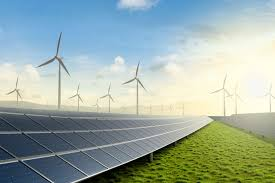

<h2 dir = 'rtl'>
מטרת המחקר היא ניתוח נתוני מחקר של אנרגייה ירוקה אשר מושפעת מנתונים שונים כגון אזורים, גודל החיסכון לכל בית , גודלו וכו,
מטרת הסיווג היא חיזוי גודל הוצאת האנרגיה אשר תלויה במשתנים רבים אשר מתוך סיווג זה אפשר להסיק רבות על אומדן הוצאת האנרגיה של בתים.


---



<h2>

<div dir="rtl">

בפרויקט שלי עבדתי עם דאטה שבו שתי המחלקות (Labels) מאוזנות – כלומר:

למרות שמאזן כזה נשמע אידיאלי, הוא דווקא מקשה על המודלים כמו KNN ו־SVM להגיע לביצועים גבוהים, במיוחד כשהמאפיינים (features) של שתי המחלקות **חופפים מאוד**.

---

### הבעיה

כאשר הדוגמאות של שתי המחלקות "נראות דומות" מבחינת ערכי הפיצ'רים – כלומר אין הבדל ברור ביניהן – גם מודל טוב מאוד לא יכול להבדיל ביניהן בצורה מדויקת.

במקרה כזה, אפילו אם נשתמש במודל האופטימלי ביותר, עדיין ניתקל בשיעור טעות בלתי נמנע, שנקרא:



**זהו גבול הדיוק האפשרי שאף מודל לא יכול לעבור אותו**, בגלל מגבלות שנובעות מהנתונים עצמם.

---

אם הממוצעים  והסטיות התקניות דומות – אין דרך סטטיסטית "להפריד" ביניהם. לכן, המודל לא יכול ללמוד גבול ברור בין המחלקות, ונשאר עם **אחוז הצלחה נמוך יחסית, אפילו אם הוא פועל בצורה מיטבית**.

---

### מסקנה:

> העובדה שהמודלים שלי הגיעו לדיוק של כ־60% לא מעידה על חולשה של המודל – אלא להפך.  
> במצב שבו יש איזון מוחלט בין המחלקות והפיצ'רים חופפים מאוד, 60% זו תוצאה שמצביעה על כך שהמודל **ממצה כמעט את מלוא המידע שניתן להפיק** מהנתונים.  
> זה מראה שהמודל עובד נכון – אבל מגבלות הדאטה עצמן הן אלו שקובעות את הגבול העליון של הדיוק.

</div>


In [ ]:
#יבוא ספריות
import pandas  as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder





#<h1 dir='rtl'>טעינת נתונים</h1>



[מסד הנתונים](https://www.kaggle.com/datasets/hajraamir21/global-renewable-energy-usage-2020-2024/data)

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/yehonatanm1/resources/refs/heads/main/Renewable_Energy_Usage_Sampled%20(1).csv')#יבוא מסד הנתונים
knn_df = df.copy()
df

,Household_ID,Region,Country,Energy_Source,Monthly_Usage_kWh,Year,Household_Size,Income_Level,Urban_Rural,Adoption_Year,Subsidy_Received,Cost_Savings_USD
0,H01502,North America,USA,Hydro,1043.49,2024,5,Low,Urban,2012,No,10.46
1,H02587,Australia,Australia,Geothermal,610.01,2024,4,High,Rural,2023,No,43.49
2,H02654,North America,USA,Biomass,1196.75,2024,8,Low,Rural,2017,Yes,93.28
3,H01056,South America,Colombia,Biomass,629.67,2024,7,High,Urban,2023,No,472.85
4,H00706,Africa,Egypt,Hydro,274.46,2022,7,Middle,Rural,2010,No,65.98
...,...,...,...,...,...,...,...,...,...,...,...,...
995,H04712,Asia,Japan,Wind,1056.65,2021,6,Middle,Urban,2018,No,307.67
996,H02314,North America,USA,Wind,1182.33,2020,2,High,Rural,2019,No,125.96
997,H03215,Europe,Germany,Wind,417.88,2023,6,Middle,Rural,2010,Yes,273.25
998,H02733,Australia,Australia,Biomass,258.91,2020,7,Middle,Urban,2017,Yes,224.35


#<h1 dir='rtl'>תיאור המשתנים במאגר הנתונים</h1>

Household_ID	קטגוריאלי

Region	קטגוריאלי

Country	קטגוריאלי

Energy_Source	קטגוריאלי

Monthly_Usage_kWh	רציף

Year	בדיד

Household_Size	בדיד

Income_Level	קטגוריאלי

Urban_Rural	קטגוריאלי

Adoption_Year	בדיד

Subsidy_Received	קטגוריאלי

Cost_Savings_USD	רציף


<p dir="rtl"> משתנה רציף (Continuous): יכול לקבל כל ערך מספרי, כולל מספרים עשרוניים, והוא מתקבל מתהליך מדידה (למשל, צריכת חשמל, משקל, גובה).</p>
<p dir="rtl"> משתנה בדיד (Discrete): יכול לקבל רק ערכים שלמים, והוא מתקבל מתהליך ספירה (למשל, מספר אנשים במשק בית, שנה מסוימת).</p>
<p dir="rtl"> משתנה קטגוריאלי (Categorical): מייצג קטגוריות או קבוצות ללא ערך מספרי טבעי, ואין לו משמעות מתמטית (למשל, מדינה, מקור אנרגיה, רמת הכנסה).</p>

#<h1 dir='rtl'>בדיקת מאפייני הנתונים</h1>

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Household_ID       1000 non-null   object 
 1   Region             1000 non-null   object 
 2   Country            1000 non-null   object 
 3   Energy_Source      1000 non-null   object 
 4   Monthly_Usage_kWh  1000 non-null   float64
 5   Year               1000 non-null   int64  
 6   Household_Size     1000 non-null   int64  
 7   Income_Level       1000 non-null   object 
 8   Urban_Rural        1000 non-null   object 
 9   Adoption_Year      1000 non-null   int64  
 10  Subsidy_Received   1000 non-null   object 
 11  Cost_Savings_USD   1000 non-null   float64
dtypes: float64(2), int64(3), object(7)
memory usage: 93.9+ KB


#<h2 dir='rtl'>הצגת השורות הראשונות</h2>
<div dir='rtl'>
פעולה זו מציגה את 5 השורות הראשונות כדי להבין את מבנה הנתונים ולראות דוגמאות של הערכים.
</div>


In [ ]:
df.head()#משתנה בדיד ורציף

,Household_ID,Region,Country,Energy_Source,Monthly_Usage_kWh,Year,Household_Size,Income_Level,Urban_Rural,Adoption_Year,Subsidy_Received,Cost_Savings_USD
0,H01502,North America,USA,Hydro,1043.49,2024,5,Low,Urban,2012,No,10.46
1,H02587,Australia,Australia,Geothermal,610.01,2024,4,High,Rural,2023,No,43.49
2,H02654,North America,USA,Biomass,1196.75,2024,8,Low,Rural,2017,Yes,93.28
3,H01056,South America,Colombia,Biomass,629.67,2024,7,High,Urban,2023,No,472.85
4,H00706,Africa,Egypt,Hydro,274.46,2022,7,Middle,Rural,2010,No,65.98


#<h2 dir='rtl'>מספר ערכים ייחודיים לכל עמודה</h2>
<div dir='rtl'>
בדיקה זו עוזרת להבין את מגוון הערכים בכל משתנה וזיהוי משתנים קטגוריים.
</div>

In [ ]:
df.nunique()

,0
Household_ID,1000
Region,6
Country,25
Energy_Source,5
Monthly_Usage_kWh,995
Year,5
Household_Size,8
Income_Level,3
Urban_Rural,2
Adoption_Year,15


#<h2 dir='rtl'>שמות העמודות</h2>

In [ ]:
df.columns

Index(['Household_ID', 'Region', 'Country', 'Energy_Source',
       'Monthly_Usage_kWh', 'Year', 'Household_Size', 'Income_Level',
       'Urban_Rural', 'Adoption_Year', 'Subsidy_Received', 'Cost_Savings_USD'],
      dtype='object')

#<h2 dir='rtl'>ספירת ערכים תקינים</h2>

In [ ]:
df.count()


,0
Household_ID,1000
Region,1000
Country,1000
Energy_Source,1000
Monthly_Usage_kWh,1000
Year,1000
Household_Size,1000
Income_Level,1000
Urban_Rural,1000
Adoption_Year,1000


#<h2 dir='rtl'>סטטיסטיקות ת</h2>
<div dir='rtl'>
הפקודה מציגה סטטיסטיקות תיאוריות עבור עמודות מספריות ב-DataFrame.<br><br>

<ul>
  <li><b>count</b> – מספר הערכים (לא ריקים)</li>
  <li><b>mean</b> – ממוצע</li>
  <li><b>std</b> – סטיית תקן (כמה הנתונים מפוזרים)</li>
  <li><b>min</b> – הערך הכי קטן</li>
  <li><b>25%</b> – רבעון ראשון</li>
  <li><b>50%</b> – חציון (ממוקם באמצע)</li>
  <li><b>75%</b> – רבעון שלישי</li>
  <li><b>max</b> – הערך הכי גדול</li>
</ul>

In [ ]:
df.describe()

,Monthly_Usage_kWh,Year,Household_Size,Adoption_Year,Cost_Savings_USD
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,767.325530,2021.992000,4.480000,2015.992000,248.389850
std,419.649102,1.419137,2.297581,3.973629,143.127301
min,50.740000,2020.000000,1.000000,2010.000000,10.420000
25%,402.730000,2021.000000,2.000000,2013.000000,122.122500
50%,760.190000,2022.000000,5.000000,2016.000000,242.530000
75%,1117.747500,2023.000000,6.000000,2019.000000,372.520000
max,1497.340000,2024.000000,8.000000,2024.000000,499.830000


#<h2 dir='rtl'>בדיקת ערכים חסרים</h2>
<div dir='rtl'>
ספירת הערכים החסרים בכל עמודה - חשוב לזהות בעיות באיכות הנתונים.
</div>

In [ ]:
df.isna().sum()


,0
Household_ID,0
Region,0
Country,0
Energy_Source,0
Monthly_Usage_kWh,0
Year,0
Household_Size,0
Income_Level,0
Urban_Rural,0
Adoption_Year,0


#<h2 dir='rtl'>בדיקת שורות כפולות</h2>

In [ ]:
duplicate_rows = df[df.duplicated()]
print(duplicate_rows)

Empty DataFrame
Columns: [Household_ID, Region, Country, Energy_Source, Monthly_Usage_kWh, Year, Household_Size, Income_Level, Urban_Rural, Adoption_Year, Subsidy_Received, Cost_Savings_USD]
Index: []


#<h1>---------------------------------------------------------------------------------------------------------------------------------------</h1>

#<h1 dir='rtl'>ניתוח נתונים מקדים</h1>

#<h2 dir='rtl'>צריכה ממוצעת לפי אזור</h2>
<div dir='rtl'>
חישוב הצריכה החודשית הממוצעת של כל אזור גיאוגרפי לזיהוי הבדלים אזוריים.
</div>

In [ ]:
average_usage_by_region = df.groupby('Region')['Monthly_Usage_kWh'].mean()
print(average_usage_by_region)

Region
Africa           778.246048
Asia             780.085706
Australia        725.285210
Europe           792.528613
North America    747.509512
South America    779.414639
Name: Monthly_Usage_kWh, dtype: float64


#<h2 dir='rtl'>חיסכון ממוצע לפי מדינה ומקור אנרגיה</h2>
<div dir='rtl'>
ניתוח החיסכון הכספי הממוצע לפי שילוב של מדינה ומקור אנרגיה.
</div>

In [ ]:
average_usage_by_region_and_source = df.groupby(['Country', 'Energy_Source'])['Cost_Savings_USD'].mean()
average_usage_by_region_and_source


Country    Energy_Source
Argentina  Biomass          274.800000
           Geothermal       148.370000
           Hydro            328.382500
           Solar            220.313333
           Wind             309.612727
                               ...    
USA        Biomass          231.801000
           Geothermal       251.865000
           Hydro            207.226000
           Solar            282.391538
           Wind             231.896154
Name: Cost_Savings_USD, Length: 125, dtype: float64

#<h1>ויזואליזציה</h1>



<div dir='rtl'>
ניתוח החיסכון הכספי הממוצע לפי שילוב של מדינה ומקור אנרגיה.
הנתונים מאוזנים.
</div>
>

---




<ipython-input-52-01828dc3abf5>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Energy_Source", y="Monthly_Usage_kWh",palette="viridis")


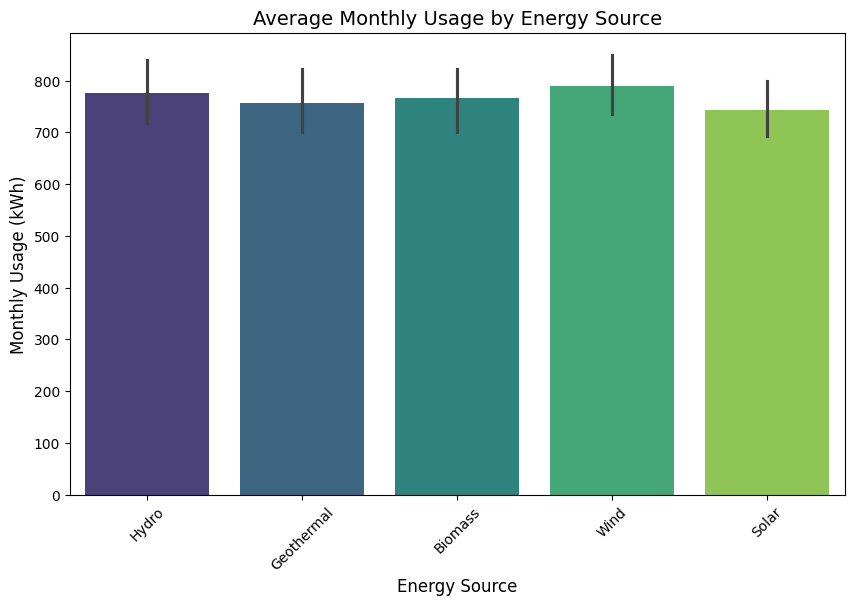

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="Energy_Source", y="Monthly_Usage_kWh",palette="viridis")
plt.title("Average Monthly Usage by Energy Source", fontsize=14)
plt.xlabel("Energy Source", fontsize=12)
plt.ylabel("Monthly Usage (kWh)", fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [ ]:
df.head()

,Household_ID,Region,Country,Energy_Source,Monthly_Usage_kWh,Year,Household_Size,Income_Level,Urban_Rural,Adoption_Year,Subsidy_Received,Cost_Savings_USD
0,H01502,North America,USA,Hydro,1043.49,2024,5,Low,Urban,2012,No,10.46
1,H02587,Australia,Australia,Geothermal,610.01,2024,4,High,Rural,2023,No,43.49
2,H02654,North America,USA,Biomass,1196.75,2024,8,Low,Rural,2017,Yes,93.28
3,H01056,South America,Colombia,Biomass,629.67,2024,7,High,Urban,2023,No,472.85
4,H00706,Africa,Egypt,Hydro,274.46,2022,7,Middle,Rural,2010,No,65.98


<h3>הצריכה במשק הבית עירוני שווה אל מול הצריכה בבתים כפריים</h3>

<ipython-input-54-d4cd50c2ee3b>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Urban_Rural", y="Monthly_Usage_kWh",palette="viridis")


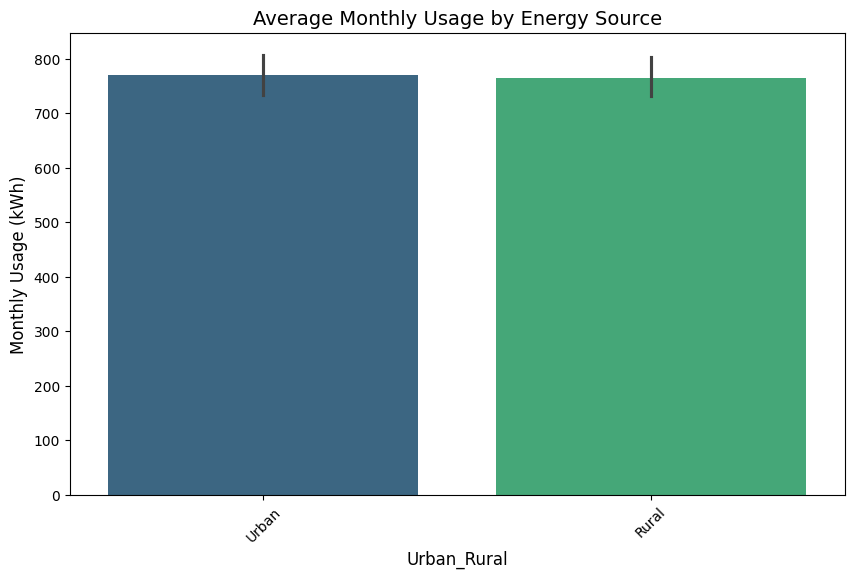

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="Urban_Rural", y="Monthly_Usage_kWh",palette="viridis")
plt.title("Average Monthly Usage by Energy Source", fontsize=14)
plt.xlabel("Urban_Rural", fontsize=12)
plt.ylabel("Monthly Usage (kWh)", fontsize=12)
plt.xticks(rotation=45)
plt.show()

#<h2 dir='rtl'>פיזור חיסכון עלויות לפי רמת הכנסה</h2>
<div dir='rtl'>
גרף תיבה המציג את התפלגות החיסכון הכספי עבור כל רמת הכנסה, כולל חציון, רבעונים וערכים חריגים.
</div>
<div dir='rtl'>

<div> רמת החיסכון שווה בסטייה מזערית בין רמות ההכנסה</div>


<ipython-input-55-be26fe2d46af>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Income_Level", y="Cost_Savings_USD", palette="coolwarm")


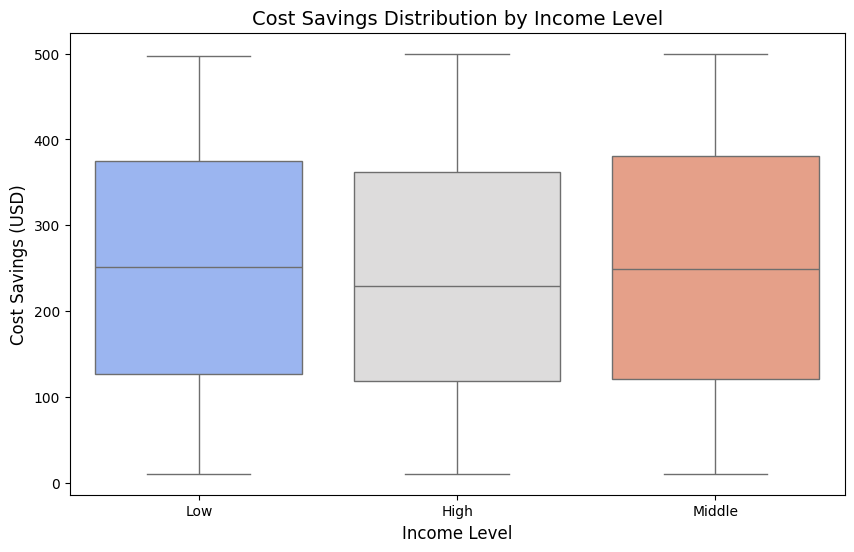

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Income_Level", y="Cost_Savings_USD", palette="coolwarm")
plt.title("Cost Savings Distribution by Income Level", fontsize=14)
plt.xlabel("Income Level", fontsize=12)
plt.ylabel("Cost Savings (USD)", fontsize=12)
plt.show()

#<h2 dir='rtl'>התפלגות אזורים</h2>
<div dir='rtl'>
גרף עוגה המציג את החלק היחסי של כל אזור גיאוגרפי במאגר הנתונים.
</div>
<div dir='rtl'>
<div>הנתונים נמצאים במצב מאוזן יחסית

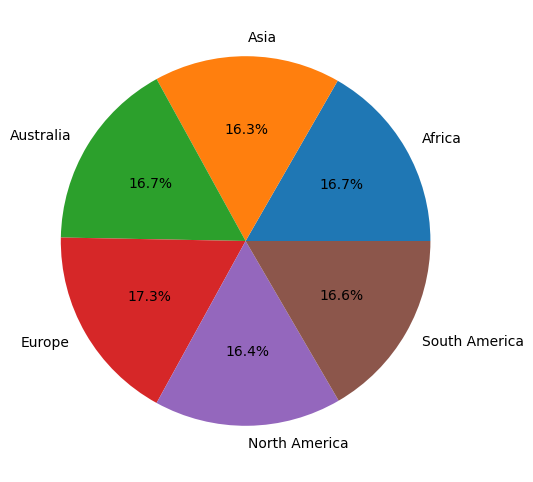

In [ ]:
plt.figure(figsize = (10,6))
pp=df.groupby('Region')['Income_Level'].count()
plt.pie(pp,labels=pp.index,autopct='%1.1f%%')
plt.show()

#<h2 dir='rtl'>קשר בין גודל משק בית לחיסכון עלויות</h2>
<div dir='rtl'>
גרף פיזור המציג את הקשר בין גודל משק הבית לחיסכון הכספי, עם הבחנה בין עירוני לכפרי.
</div>

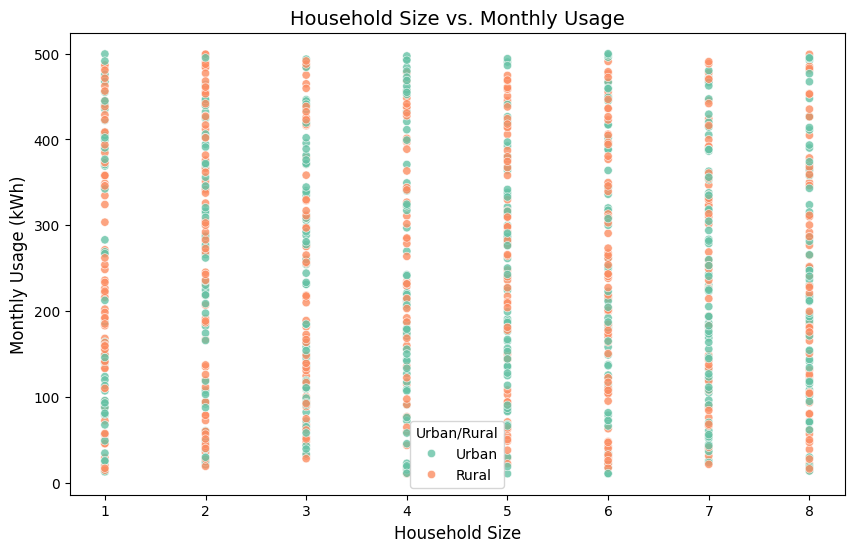

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Household_Size", y="Cost_Savings_USD", hue="Urban_Rural", palette="Set2", alpha=0.8)#רציף אל מול רציף
plt.title("Household Size vs. Monthly Usage", fontsize=14)
plt.xlabel("Household Size", fontsize=12)
plt.ylabel("Monthly Usage (kWh)", fontsize=12)
plt.legend(title="Urban/Rural", fontsize=10)
plt.show()

#<h2 dir='rtl'>התפלגות שנת אימוץ הטכנולוגיה</h2>
<div dir='rtl'>
היסטוגרמה המציגה את התפלגות שנות האימוץ של האנרגיה המתחדשת, עם עקומת צפיפות.
</div>

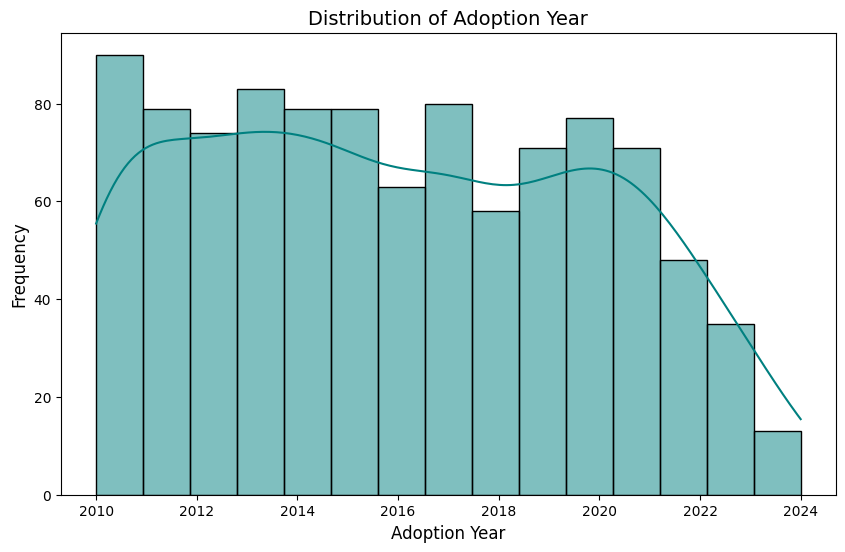

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="Adoption_Year", bins=15, kde=True, color="teal")#bins = size of boxplot
plt.title("Distribution of Adoption Year", fontsize=14)
plt.xlabel("Adoption Year", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

#<h2 dir='rtl'>התפלגות צריכה לפי רמת הכנסה</h2>
<div dir='rtl'>
גרף כינור המציג את התפלגות הצריכה החודשית עבור כל רמת הכנסה, כולל צפיפות הערכים.
</div>
<div dir='rtl'>
למרות שהצריכה החודשית דומה בין רמות ההכנסה, עדיין קיימים הבדלים קלים בתפלגות ובשונות בין הקבוצות.
</div>


<ipython-input-59-5a11b6eae78a>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Income_Level", y="Monthly_Usage_kWh", palette="muted")


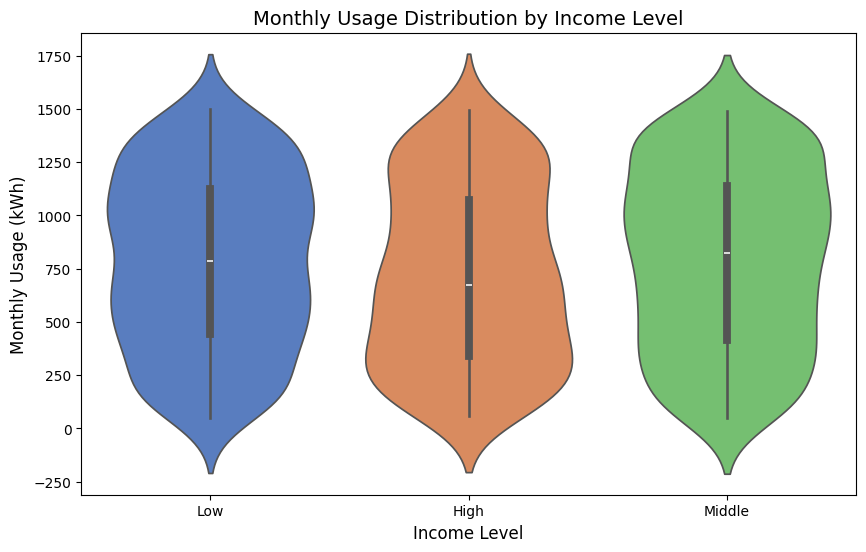

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="Income_Level", y="Monthly_Usage_kWh", palette="muted")
plt.title("Monthly Usage Distribution by Income Level", fontsize=14)
plt.xlabel("Income Level", fontsize=12)
plt.ylabel("Monthly Usage (kWh)", fontsize=12)
plt.show()

#<h1 dir='rtl'>מטריצת קורלציה</h1>
<div dir='rtl'>
יצירת מטריצת קורלציה בין כל המשתנים המספריים לזיהוי קשרים ליניאריים בין המשתנים. ובעיקר לעומת משתנה המטרה
</div>

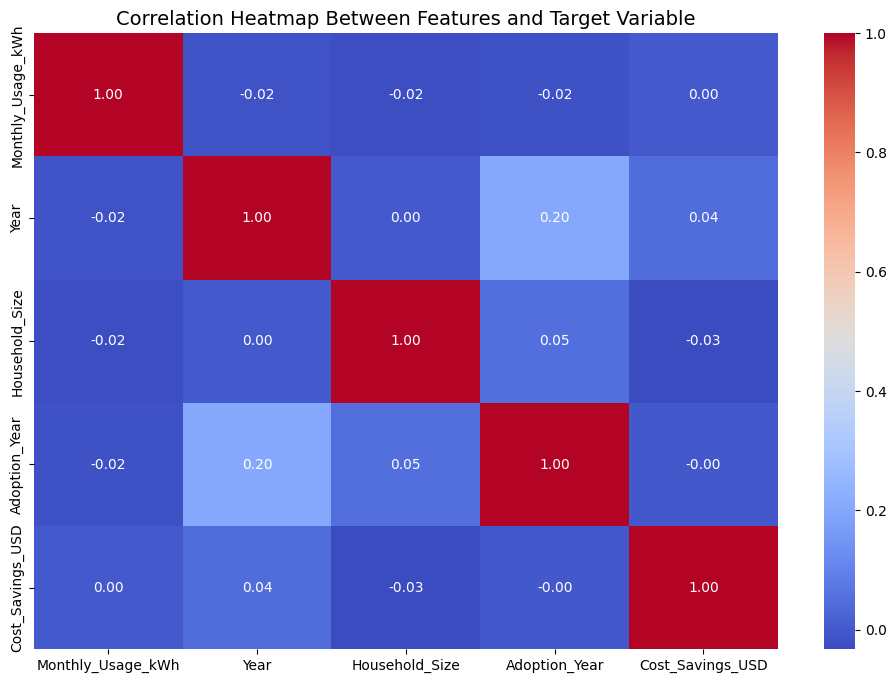

In [ ]:
numerical_data = df.select_dtypes(include=["number"])

correlation_matrix = numerical_data.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap Between Features and Target Variable", fontsize=14)
plt.show()


In [ ]:
#יבוא ספריות
###############################return
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt


# Knn

In [ ]:
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# טעינת הנתונים
df = pd.read_csv('https://raw.githubusercontent.com/yehonatanm1/resources/refs/heads/main/Renewable_Energy_Usage_Sampled%20(1).csv')

# מחיקת עמודות לא רלוונטיות
del_col = ['Household_ID']  #
df.drop(del_col, axis=1, inplace=True)

# זיהוי משתנים קטגוריים
categorical_cols = ['Region', 'Country', 'Energy_Source', 'Income_Level', 'Urban_Rural', 'Subsidy_Received']

encoder = OneHotEncoder(sparse_output=False, drop='first')
categorical_encoded = encoder.fit_transform(df[categorical_cols])#מתאים את המקודד על העמודות הקטגוריות ומבצע קידוד
categorical_df = pd.DataFrame(categorical_encoded, columns=encoder.get_feature_names_out(categorical_cols))
#↑↑↑↑↑↑
#זהו המערך שמכיל את המספרים(הבינאריים לרוב) אחרי הקידוד categorical_encoded

# שילוב הנתונים מחדש
df = df.drop(columns=categorical_cols).reset_index(drop=True)
df = pd.concat([df, categorical_df], axis=1)#
#######################################################



In [ ]:
print(categorical_encoded)

[[0. 0. 0. ... 0. 1. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 ...
 [0. 0. 1. ... 1. 0. 1.]
 [0. 1. 0. ... 1. 1. 1.]
 [0. 1. 0. ... 0. 1. 0.]]


Accuracy: 0.60
Classification Report:
              precision    recall  f1-score   support

        High       0.66      0.67      0.66       117
         Low       0.52      0.51      0.51        83

    accuracy                           0.60       200
   macro avg       0.59      0.59      0.59       200
weighted avg       0.60      0.60      0.60       200

Confusion Matrix:
[[78 39]
 [41 42]]


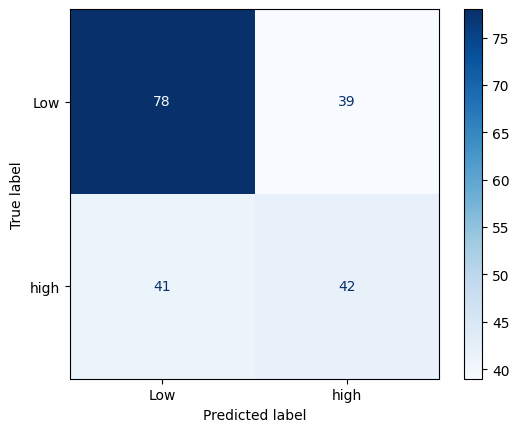

In [ ]:
bins = [0, 700, np.inf]  # חלוקה לפי צריכה ה
labels = ['Low', 'High']
df['Monthly_Usage_Category'] = pd.cut(df['Monthly_Usage_kWh'], bins=bins, labels=labels)

#הפרדת משתנים מסבירים ומשתנה מטרה
X = df.drop(columns=['Monthly_Usage_kWh', 'Monthly_Usage_Category'])#הכל חוץ מהעמודות הנבחרות האלו
y = df['Monthly_Usage_Category']#משתנה מטרה
#חלוקת הנתונים ל-80% לאימון ו-20% לבדיקה כדי להעריך את ביצועי המודל על נתונים לא מוכרים
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#בוצע נרמול מסוג MinMax אשר מביא את כל המשתנים לטווח של 0 עד 1. נרמול זה חשוב במיוחד באלגוריתם KNN, כיוון שהוא מבוסס על חישוב מרחקים בין נקודות, והבדלים בין סולמות מדידה של משתנים עשויים להשפיע על דיוק הסיווג.
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#אימון המודל עם ערך k=3 תחילה
knn_classifier = KNeighborsClassifier(n_neighbors=3)
knn_classifier.fit(X_train_scaled,y_train)
y_pred = knn_classifier.predict(X_test_scaled)
#בדיקת דיוק המודל
accuracy = accuracy_score(y_test,y_pred)
report = classification_report(y_test,y_pred)
conf_matrix = confusion_matrix(y_test,y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(report)
print("Confusion Matrix:")
print(conf_matrix)
conf_matrix = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(conf_matrix,display_labels=["Low", "high"])
disp.plot(cmap='Blues',values_format="d")
plt.show()



<h3 dir = 'rtl'> בדיקה של ערכי k שונים למציאת הערך החיזוי האופטימלי שיניב את החיזוי הטוב ביותר<h3>

In [ ]:
#יבוא ספריות
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# טעינת הנתונים
df = pd.read_csv('https://raw.githubusercontent.com/yehonatanm1/resources/refs/heads/main/Renewable_Energy_Usage_Sampled%20(1).csv')

# מחיקת עמודות לא רלוונטיות
del_col = ['Household_ID']  # השארתי את 'Year' לבדיקה אם הוא מועיל
df.drop(del_col, axis=1, inplace=True)

# זיהוי משתנים קטגוריים
categorical_cols = ['Region','Country','Energy_Source','Income_Level','Urban_Rural','Subsidy_Received']

encoder = OneHotEncoder(sparse_output=False, drop='first')
categorical_encoded = encoder.fit_transform(df[categorical_cols])
categorical_df = pd.DataFrame(categorical_encoded, columns=encoder.get_feature_names_out(categorical_cols))

# שילוב הנתונים מחדש
df = df.drop(columns=categorical_cols).reset_index(drop=True)
df = pd.concat([df, categorical_df], axis=1)
#######################################################
bins = [0, 700, np.inf]  # דוגמה לחלוקה לפי צריכה נמוכה, בינונית וגבוהה
labels = ['Low', 'High']
df['Monthly_Usage_Category'] = pd.cut(df['Monthly_Usage_kWh'], bins=bins, labels=labels)

# הפרדת משתנה המטרה מהפיצ'רים
X = df.drop(columns=['Monthly_Usage_kWh', 'Monthly_Usage_Category'])
y = df['Monthly_Usage_Category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
for k in range(3,20,4):

  knn_classifier = KNeighborsClassifier(n_neighbors=k)
  knn_classifier.fit(X_train_scaled, y_train)
  y_pred = knn_classifier.predict(X_test_scaled)

  accuracy = accuracy_score(y_test, y_pred)
  report = classification_report(y_test, y_pred)
  conf_matrix = confusion_matrix(y_test, y_pred)

  print(f"for k = {k} - ")
  print(f"Accuracy: {accuracy:.2f}")



for k = 3 - 
Accuracy: 0.60
for k = 7 - 
Accuracy: 0.54
for k = 11 - 
Accuracy: 0.53
for k = 15 - 
Accuracy: 0.53
for k = 19 - 
Accuracy: 0.53


<h2 dir='rtl'>גרפים על מנת להראות משתנה החיזוי  ביחס למסביר</h2>
<div dir='rtl'>
הצגת הקשר בין גודל משק הבית לצריכה החודשית בשני סוגי גרפים.
</div>

<ipython-input-66-26d21b4e5fa1>:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=df, x="Household_Size", y="Monthly_Usage_kWh",palette="viridis")


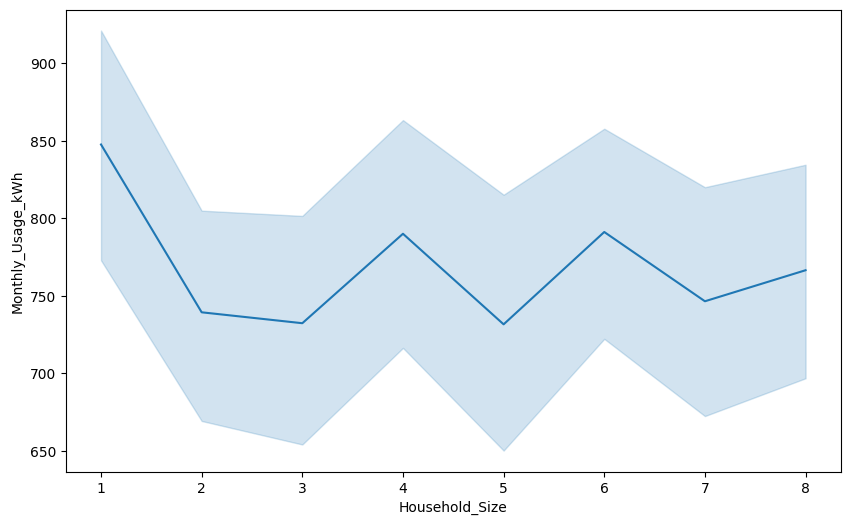

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Household_Size", y="Monthly_Usage_kWh",palette="viridis")
plt.show()

<ipython-input-67-446912b2a58e>:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x="Household_Size", y="Monthly_Usage_kWh",palette="viridis")


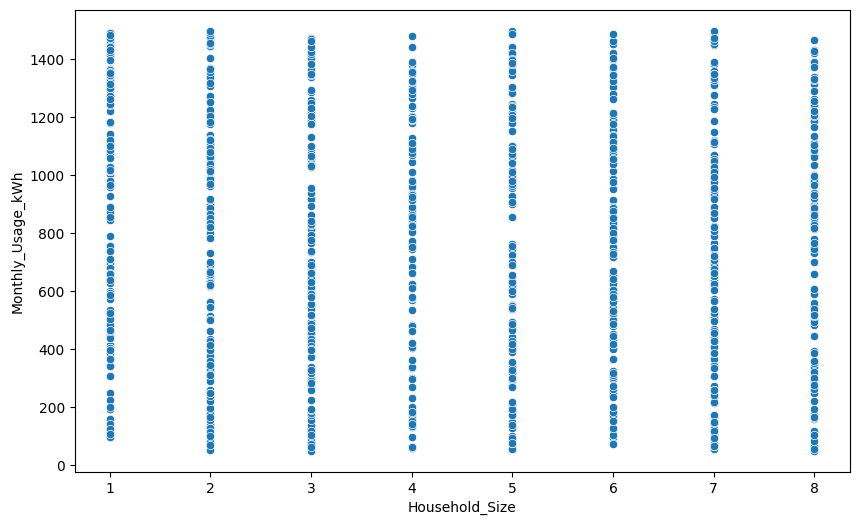

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Household_Size", y="Monthly_Usage_kWh",palette="viridis")
plt.show()

# SVM - Support Vector Machine

In [ ]:
#יבוא ספריות
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
#שימוש באותם נתונים מעובדים של המודל הקודם.

X = df.drop(columns=['Monthly_Usage_kWh', 'Monthly_Usage_Category'])
y = df['Monthly_Usage_Category']

# חלוקה לסט אימון וסט בדיקה (70%-30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# יצירת מודל SVM עם Kernel RBF ו-C=1

In [ ]:
svm_model = SVC(kernel='rbf', C=1)

    # התאמת המודל לנתונים
svm_model.fit(X_train, y_train)

    # חיזוי על סט הבדיקה
y_pred = svm_model.predict(X_test)

print("accuracy: ", accuracy_score(y_test, y_pred))

accuracy:  0.5833333333333334


In [ ]:
#בדיקה על פי סוגי חלוקת הנתונים במודל במקביל לבדיקת גודל הקו המפריד המובע בעזרת C
kernel_type = ['linear', 'poly', 'rbf', 'sigmoid']
c_index = [0.01, 0.1, 1, 10, 100]
for kernel in kernel_type:
  for index in c_index:
    svm_model = SVC(kernel=kernel, C=index)

    # התאמת המודל לנתונים
    svm_model.fit(X_train, y_train)

    # חיזוי על סט הבדיקה
    y_pred = svm_model.predict(X_test)

    print(f"for {kernel} in C index of {index}: ")
    print("accuracy: ", accuracy_score(y_test, y_pred))
  print("next test:_____________________")


for linear in C index of 0.01: 
accuracy:  0.5833333333333334
for linear in C index of 0.1: 
accuracy:  0.5133333333333333
for linear in C index of 1: 
accuracy:  0.49
for linear in C index of 10: 
accuracy:  0.52
for linear in C index of 100: 
accuracy:  0.53
next test:_____________________
for poly in C index of 0.01: 
accuracy:  0.5833333333333334
for poly in C index of 0.1: 
accuracy:  0.5833333333333334
for poly in C index of 1: 
accuracy:  0.5833333333333334
for poly in C index of 10: 
accuracy:  0.5833333333333334
for poly in C index of 100: 
accuracy:  0.5833333333333334
next test:_____________________
for rbf in C index of 0.01: 
accuracy:  0.5833333333333334
for rbf in C index of 0.1: 
accuracy:  0.5833333333333334
for rbf in C index of 1: 
accuracy:  0.5833333333333334
for rbf in C index of 10: 
accuracy:  0.5833333333333334
for rbf in C index of 100: 
accuracy:  0.5833333333333334
next test:_____________________
for sigmoid in C index of 0.01: 
accuracy:  0.5833333333333334

In [ ]:
df

,Monthly_Usage_kWh,Year,Household_Size,Adoption_Year,Cost_Savings_USD,Region_Asia,Region_Australia,Region_Europe,Region_North America,Region_South America,...,Country_USA,Energy_Source_Geothermal,Energy_Source_Hydro,Energy_Source_Solar,Energy_Source_Wind,Income_Level_Low,Income_Level_Middle,Urban_Rural_Urban,Subsidy_Received_Yes,Monthly_Usage_Category
0,1043.49,2024,5,2012,10.46,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,High
1,610.01,2024,4,2023,43.49,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Low
2,1196.75,2024,8,2017,93.28,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,High
3,629.67,2024,7,2023,472.85,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,Low
4,274.46,2022,7,2010,65.98,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1056.65,2021,6,2018,307.67,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,High
996,1182.33,2020,2,2019,125.96,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,High
997,417.88,2023,6,2010,273.25,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,Low
998,258.91,2020,7,2017,224.35,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,Low


# LinearRegression

In [ ]:
#יבוא ספריות
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt





In [ ]:
df

,Monthly_Usage_kWh,Year,Household_Size,Adoption_Year,Cost_Savings_USD,Region_Asia,Region_Australia,Region_Europe,Region_North America,Region_South America,...,Country_USA,Energy_Source_Geothermal,Energy_Source_Hydro,Energy_Source_Solar,Energy_Source_Wind,Income_Level_Low,Income_Level_Middle,Urban_Rural_Urban,Subsidy_Received_Yes,Monthly_Usage_Category
0,1043.49,2024,5,2012,10.46,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,High
1,610.01,2024,4,2023,43.49,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Low
2,1196.75,2024,8,2017,93.28,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,High
3,629.67,2024,7,2023,472.85,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,Low
4,274.46,2022,7,2010,65.98,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1056.65,2021,6,2018,307.67,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,High
996,1182.33,2020,2,2019,125.96,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,High
997,417.88,2023,6,2010,273.25,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,Low
998,258.91,2020,7,2017,224.35,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,Low


In [ ]:
freq_df = df["Adoption_Year"].value_counts().reset_index()
freq_df.columns = ["Adoption_Year", "Frequency"]

X = freq_df["Adoption_Year"].values.reshape(-1, 1)  # מסביר
y = freq_df["Frequency"].values  # תדירות כמשתנה מוסבר
#הגדרת המודל
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)


In [ ]:
knn_df

,Household_ID,Region,Country,Energy_Source,Monthly_Usage_kWh,Year,Household_Size,Income_Level,Urban_Rural,Adoption_Year,Subsidy_Received,Cost_Savings_USD
0,H01502,North America,USA,Hydro,1043.49,2024,5,Low,Urban,2012,No,10.46
1,H02587,Australia,Australia,Geothermal,610.01,2024,4,High,Rural,2023,No,43.49
2,H02654,North America,USA,Biomass,1196.75,2024,8,Low,Rural,2017,Yes,93.28
3,H01056,South America,Colombia,Biomass,629.67,2024,7,High,Urban,2023,No,472.85
4,H00706,Africa,Egypt,Hydro,274.46,2022,7,Middle,Rural,2010,No,65.98
...,...,...,...,...,...,...,...,...,...,...,...,...
995,H04712,Asia,Japan,Wind,1056.65,2021,6,Middle,Urban,2018,No,307.67
996,H02314,North America,USA,Wind,1182.33,2020,2,High,Rural,2019,No,125.96
997,H03215,Europe,Germany,Wind,417.88,2023,6,Middle,Rural,2010,Yes,273.25
998,H02733,Australia,Australia,Biomass,258.91,2020,7,Middle,Urban,2017,Yes,224.35


In [ ]:
# יצירת טבלה חדשה שמציגה את מספר האימוצים לכל שנה
freq_df = df["Adoption_Year"].value_counts().reset_index()
# המאפיין X הוא שנת האימוץ, והיעד y הוא התדירות של אותה שנה
freq_df.columns = ["Adoption_Year", "Frequency"]
X = freq_df["Adoption_Year"].values.reshape(-1, 1)# X חייב להיות בצורה של מערך דו-ממדי
y = freq_df["Frequency"].values
"""Adoption_Year([[2010],
       [2011],
       [2012],
       [2013]])"""
#סט אימון סט בדיקה יחס של 20 אחוז
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#הגדרת המודל
model = LinearRegression()
#אימון המודל על הנתונים
model.fit(X_train, y_train)

y_pred = model.predict(X_test)#חיזוי

r2 = r2_score(y_test,y_pred)
print(r2)

0.6633466310141252


<p dir='rtl'>X הוא סדרה (עמודה ב-DataFrame), אבל sklearn דורש שהקלט יהיה מטריצה דו-ממדית (2D array).</p>
<p dir='rtl'>values מחלץ את הנתונים מה-DataFrame כמערך NumPy חד-ממדי (1D array).
</p>
<p dir='rtl'>.reshape(-1, 1) משנה אותו למערך דו-ממדי של עמודה אחת, כלומר כל ערך הופך לשורה נפרדת.
ביצעתי זאת כדי להנגיש את המניפולציות על עמודה זאת
</p>

In [ ]:
freq_df

,Adoption_Year,Frequency
0,2010,90
1,2013,83
2,2017,80
3,2015,79
4,2014,79
5,2011,79
6,2020,77
7,2012,74
8,2021,71
9,2019,71


<h3 dir = 'rtl'>
חיזוי המודל, הקשר הישיר בין הנתונים על פי המודל
</h3>

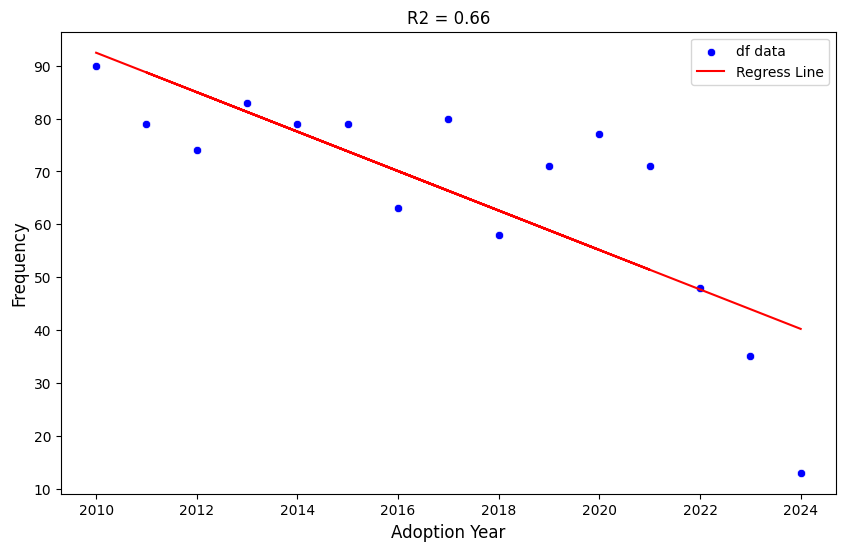

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=freq_df, x="Adoption_Year",y="Frequency",color="blue",label="df data")
plt.plot(freq_df["Adoption_Year"], model.predict(X), color="red",label="Regress Line")##ציור קו הרגרסיה שחוזה את התדירות לפי השנה
plt.title(f"R2 = {r2:.2f}")#f- עבור float
plt.xlabel("Adoption Year",fontsize=12)
plt.ylabel("Frequency",fontsize=12)
plt.legend()
plt.show()

<p dir='rtl'> מטרת המודל רגרסיה היא להראות את הקשר בין שנת תחילת השימוש ואימוץ הטכנולוגיה המתחדשת ביחס לכמות האנשים אשר משתמשים בה בכל שנה ועל מנת להראות את השינוי ההדרגתי שנפער בין השנים עד לימינו.\\ כל שנה נבחנה עד סופה גם 2024.

<div dir = 'rtl'>
<h1>סיכום</h1>
<h3>הנתונים כללו משתנים כמו אזור גאוגרפי, סוג מקור האנרגיה, רמת הכנסה, אורבני/כפרי ועוד. רוב המשתנים היו קטגוריים, ולכן נדרש קידוד מתאים (OneHotEncoding). חלק מהעמודות הכילו הרבה קטגוריות (כמו מדינות), מה שיצר הרבה עמודות חדשות והשפיע על המודלים.

ההשערה שלי הייתה שמודלים פשוטים כמו KNN יתנו תוצאה טובה, כי הנתונים יחסית ברורים. בפועל, KNN הצליח ברמה בינונית – כנראה בגלל הרגישות שלו למרחקים בין נתונים, מה שחייב נרמול. SVM נתן ביצועים מעט יותר טובים, ככל הנראה כי הוא מסוגל להפריד בין קבוצות בצורה לא ליניארית. ברגרסיה ליניארית מצאתי מגמה של עלייה באימוץ אנרגיה מתחדשת לאורך השנים, מה שמראה תהליך של מעבר הדרגתי לאנרגיה ירוקה.

בסך הכול, ככל שהנתונים עברו יותר עיבוד וניקוי – כך הביצועים של המודלים השתפרו. הקידוד והנרמול השפיעו בצורה משמעותית על התוצאה.

</h3>
<h3>מהעבודה הזאת למדתי איך להכין נתונים למודלים של למידת מכונה – במיוחד איך לקודד טקסט למספרים, ואיך לנרמל משתנים כדי שהמודלים יעבדו כמו שצריך. העמקתי בלמידה על מודלים כמו KNN ו-SVM, והבנתי יותר טוב איך הם עובדים ומה ההבדלים ביניהם.

האתגרים העיקריים היו להבין איך להתמודד עם עמודות שיש להן הרבה ערכים (כמו מדינות), ואיך לבחור איזה מודל מתאים לכל סוג של בעיה. לפעמים גם היה קשה להבין את התוצאות ולפרש אם המודל באמת מדויק או לא.

במהלך הפרויקט העמקתי לבד בנושאים כמו נרמול, OneHotEncoding, והמשמעות של Confusion Matrix. היה לי מעניין לראות איך כל שינוי קטן בנתונים משפיע על הביצועים, וזה נתן לי הרבה ביטחון להמשיך ללמוד על בינה מלאכותית וניתוח נתונים.
</h3>